## Загрузка и подготовка данных

In [2]:
#!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [3]:
#!pip install tqdm numpy matplotlib

In [4]:
import torch
from torch import nn
import torch.optim as optim

import pickle
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

import torch.nn.functional as F

In [5]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

In [6]:
# Определение преобразования
fashion_transformer = transforms.Compose([
    transforms.ToTensor(), #  преобразует изображение в тензор PyTorch и нормализует значения пикселей в диапазон [0, 1]
    transforms.Normalize(0.13, 0.31)]) # дополнительная нормализация (среднее=0.13, std=0.31) для стабилизации обучения

# Загрузка данных и применение преобразований
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=fashion_transformer
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=fashion_transformer
)

# Классы fashionMNIST
fashion_classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Размер тренировочного набора: {len(train_dataset)}")
print(f"Размер тестового набора: {len(test_dataset)}")

Размер тренировочного набора: 60000
Размер тестового набора: 10000


## Создание AlexNet

In [7]:
# Определение устройства
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cpu


In [8]:
def AlexNet():
    # xavier инициализация для линейных и сверточных слоев - помогает избежать проблем с исчезающими/взрывающимися градиентами
    def init_weights(m):
        if type(m) == torch.nn.Linear:
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01) # Инициализация смещений
        if type(m) == torch.nn.Conv2d:
            torch.nn.init.xavier_uniform_(m.weight)

    net = torch.nn.Sequential(
        # Сверточные слои
        torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1), # сверточный слой: 1 входной канал , 32 выходных канала, ядро 3x3
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28 -> 14x14 # операция макс-пулинга уменьшает размерность в 2 раза

        torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),  # 14x14 -> 7x7

        torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
        torch.nn.ReLU(),

        torch.nn.Conv2d(128, 256, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),  # 7x7 -> 3x3

        # Классификатор
        torch.nn.Flatten(), # преобразует многомерный тензор в одномерный для полносвязных слоев
        torch.nn.Dropout(0.5), # регуляризация, случайно "отключает" 50% нейронов для предотвращения переобучения
        torch.nn.Linear(256 * 3 * 3, 512), # полносвязный слой
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(512, 256),
        torch.nn.ReLU(),
        torch.nn.Linear(256, 10)
    )

    net.apply(init_weights)
    return net

model = AlexNet().to(device)
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=2304, out_features=512, bias=True)
  (14): ReLU()
  (15): Dropout(p=0.5, inplace=False)
  (16): Linear(in_features=512, out_features=256, bias=True)
  (17): ReLU()
  (18): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
# Создание DataLoader
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Функция обучение

In [10]:
def train(model, train_loader, device, num_epochs):

    # результат функции train
    train_losses = []
    train_accuracies = []

    optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # алгоритм, который обновляет веса модели, чтобы минимизировать функцию потерь

    for epoch in range(num_epochs):
        model.train()  # Режим обучения
        total_loss = 0
        total = 0
        correct = 0

        for batch_idx, (data, target) in enumerate(train_loader):

            # Перемещаем данные на устройство
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            # Прямой проход
            outputs = model(data) # прямой проход (forward pass)
            loss = F.cross_entropy(outputs, target) # вычисление функции потерь
            _, predicted = outputs.max(1)

            # Обратный проход
            loss.backward()        # Вычисляем градиенты
            optimizer.step()       # Обновляем веса

            # Статистика
            total_loss += loss.item()
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        epoch_loss = total_loss/len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')


    return train_losses, train_accuracies


In [11]:
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

In [12]:
def plot_training_history(losses, accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')

    ax2.plot(accuracies)
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.show()

## Запуск модели

In [13]:
# Параметры обучения
num_epochs = 20

# Обучение
train_losses, train_accuracies = train(model, train_loader, device, num_epochs)

Epoch [10/20], Loss: 0.4106, Accuracy: 85.0900
Epoch [20/20], Loss: 0.3283, Accuracy: 87.9933


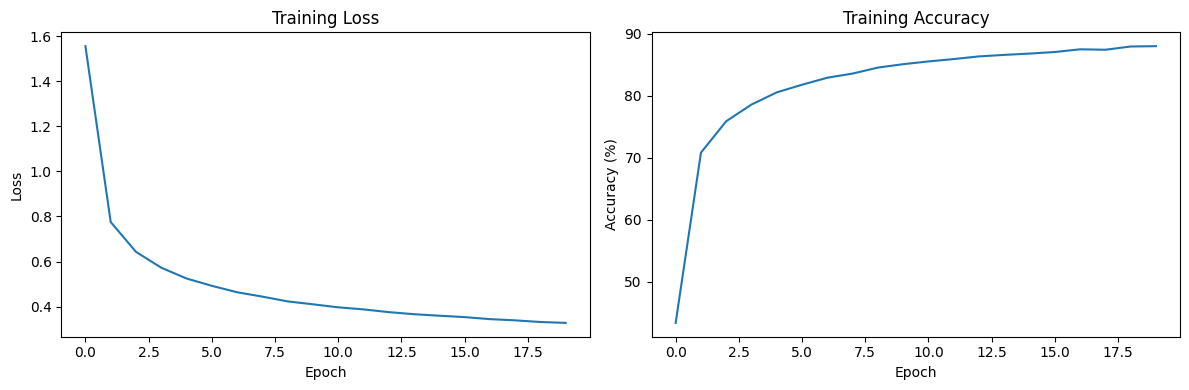

In [14]:
plot_training_history(train_losses, train_accuracies)

## Оценка

In [15]:
print("Оценка модели на тестовых данных:")
test_accuracy = evaluate(model, test_loader, device)

Оценка модели на тестовых данных:
Test Accuracy: 88.62%
